In [1]:
from made.data_pipeline.data.datacomp_handler import decode_webdataset, get_next_batch
from made.data_pipeline.utils import collect_tar_files

In [2]:
dataset = iter(decode_webdataset(
    collect_tar_files("/home/leobaro/Downloads/datasets/web/datacomp/full_datacomp_unimodal_vision_filter_output"), # 20220 samples read in 1m 10s
    get_images=True,
    get_captions=True,
    batch_size=2000
))

2025-06-16 19:34:21,000	INFO utils.py:41 -- Found 20 tar files from /home/leobaro/Downloads/datasets/web/datacomp/full_datacomp_unimodal_vision_filter_output


In [3]:

from transformers import AutoProcessor, AutoModelForZeroShotImageClassification
processor = AutoProcessor.from_pretrained("leobaro/DFN-public")
model = AutoModelForZeroShotImageClassification.from_pretrained("leobaro/DFN-public").eval().to("cuda")

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


In [4]:
uid_score = {}
i_dataset = iter(dataset)
while True:
    batch = get_next_batch(i_dataset)
    if batch is None:
        break
    uids, images, captions = batch
    print("New batch!")
    for uid, img, txt in zip(uids, images, captions):
        try:
            inputs = processor(text=[txt], images=[img], return_tensors="pt", padding=True, truncation=True, max_length=77).to("cuda")
        except Exception as e:
            print(e)
            continue
        outputs = model(**inputs)
        uid_score[uid] = outputs.logits_per_image.item()


New batch!
New batch!
New batch!
New batch!
New batch!
New batch!
New batch!
New batch!
New batch!
New batch!
New batch!
New batch!
New batch!
New batch!
New batch!
New batch!
New batch!
New batch!
New batch!
New batch!
New batch!
New batch!
New batch!
New batch!
New batch!
New batch!
New batch!


In [5]:
import pandas as pd
pd.DataFrame(uid_score.values()).describe()

,0
count,46111.000000
mean,2.959877
std,1.477490
min,-2.386162
25%,1.893348
50%,3.084493
75%,4.111238
max,7.066980


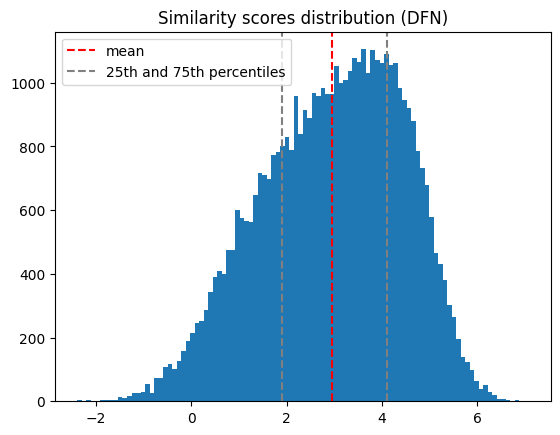

In [6]:
import matplotlib.pyplot as plt
import numpy as np
plt.title("Similarity scores distribution (DFN)")
sim_scores = list(uid_score.values())
plt.hist(sim_scores, bins=100)
plt.axvline(x=np.mean(sim_scores), color='red', linestyle='--', label='mean')
plt.axvline(x=np.percentile(sim_scores, 25), color='grey', linestyle='--', label='25th and 75th percentiles')
plt.axvline(x=np.percentile(sim_scores, 75), color='grey', linestyle='--')
plt.legend()
plt.show()


In [7]:
def find_samples_with_uids(uid_list, n):
    dataset = iter(decode_webdataset(
        collect_tar_files("/home/leobaro/Downloads/datasets/web/datacomp/full_datacomp_unimodal_vision_filter_output"), # 20220 samples read in 1m 10s
        get_images=True,
        get_captions=True,
        batch_size=n,
        valid_uids=uid_list
    ))
    uids, images, captions = get_next_batch(iter(dataset))
    return uids, images, captions


In [8]:
percentile_ranges = [(x,x+10) for x in range(50, 100, 10)]
percentile_ranges

[(50, 60), (60, 70), (70, 80), (80, 90), (90, 100)]

In [9]:
import random
data_to_plot = {}
max_samples_per_columns = 4
for row_i, percentile_range in enumerate(percentile_ranges):
    p_min, p_max = np.percentile(sim_scores, percentile_range[0]), np.percentile(sim_scores, percentile_range[1])
    print(percentile_range[0], p_min, p_max)
    uids = [uid for uid, score in uid_score.items() if score > p_min and score < p_max]
    scores = [score for uid, score in uid_score.items() if score > p_min and score < p_max]
    random_index = random.sample(range(0, len(uids)), max_samples_per_columns)
    random_uids = [uids[i] for i in random_index]
    random_scores = [scores[i] for i in random_index]
    sorted_pairs = sorted(zip(random_scores, random_uids))
    sorted_scores, sorted_uids = zip(*sorted_pairs)

    uids, images, captions = find_samples_with_uids(sorted_uids, max_samples_per_columns)
    data_to_plot[f"{percentile_range}"] = uids, images, captions, sorted_scores 


2025-06-16 19:44:50,819	INFO utils.py:41 -- Found 20 tar files from /home/leobaro/Downloads/datasets/web/datacomp/full_datacomp_unimodal_vision_filter_output


50 3.0844931602478027 3.5041115283966064


2025-06-16 19:44:56,965	INFO utils.py:41 -- Found 20 tar files from /home/leobaro/Downloads/datasets/web/datacomp/full_datacomp_unimodal_vision_filter_output


60 3.5041115283966064 3.9071538448333736


2025-06-16 19:45:02,336	INFO utils.py:41 -- Found 20 tar files from /home/leobaro/Downloads/datasets/web/datacomp/full_datacomp_unimodal_vision_filter_output


70 3.9071538448333736 4.319431781768799


2025-06-16 19:45:08,158	INFO utils.py:41 -- Found 20 tar files from /home/leobaro/Downloads/datasets/web/datacomp/full_datacomp_unimodal_vision_filter_output


80 4.319431781768799 4.799320697784424


2025-06-16 19:45:13,883	INFO utils.py:41 -- Found 20 tar files from /home/leobaro/Downloads/datasets/web/datacomp/full_datacomp_unimodal_vision_filter_output


90 4.799320697784424 7.066980361938477


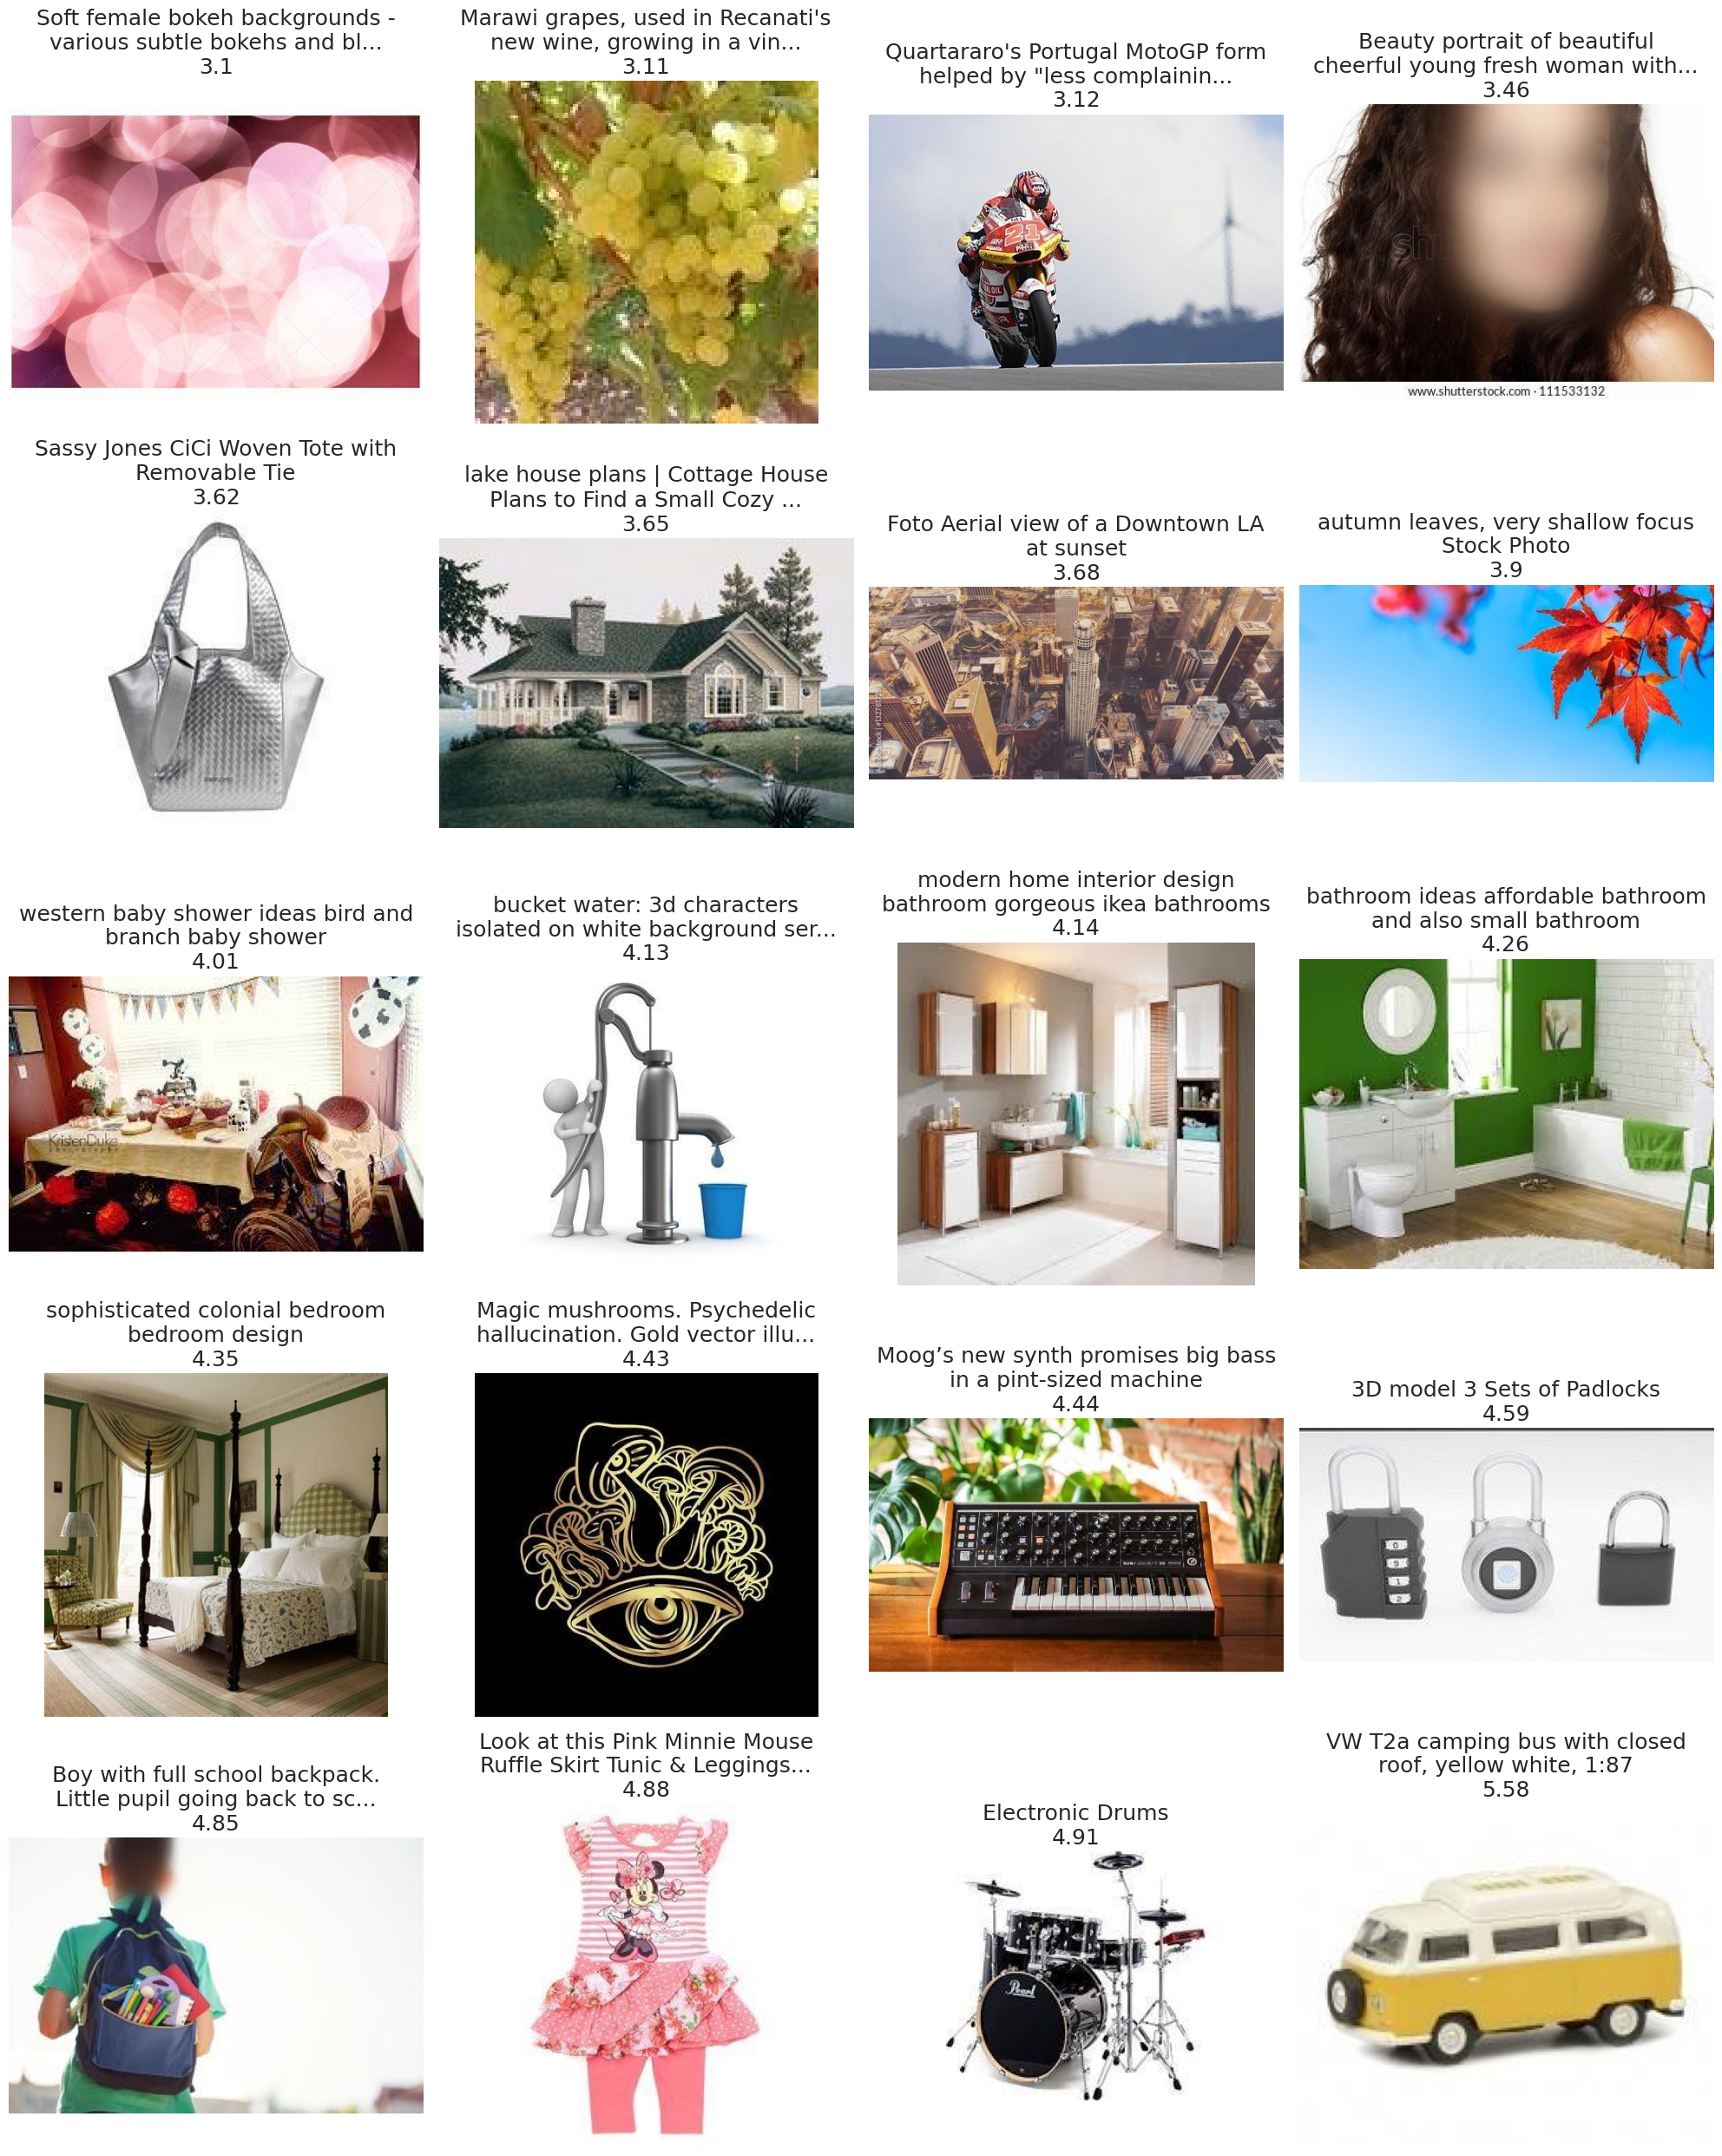

In [23]:
import seaborn as sns
import textwrap
from datetime import datetime

sns.set_theme(style="darkgrid")
num_cols = 4
num_rows = len(percentile_ranges)
fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 5 * num_rows))
#fig.suptitle("DFN similarity scores percentiles", fontsize=16)

row = 0
for percentile_range in data_to_plot.keys():
    uids, images, captions, scores = data_to_plot[percentile_range]
    row_axes = axes[row]

    col = 0
    for uid, image, caption, score in zip(uids, images, captions, scores):
        col_ax = row_axes[col] 
        col_ax.imshow(image)
        if len(caption) > 60:
            caption = caption[0:60]
            caption += "..."
        wrapped_caption = "\n".join(textwrap.wrap(caption, width=35))
        col_ax.set_title(f"{wrapped_caption}\n{round(score, 2)}", fontsize=18)
        col_ax.axis("off")
        col += 1
    row += 1
fig.tight_layout()
fig.savefig(f"dfn_percentiles_{datetime.now()}.png")